In [ ]:
import os
import re
import json
import random
from math import log
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve
from scipy.stats import pearsonr, spearmanr

import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

In [ ]:
# Optional spaCy features
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
except Exception:
    SPACY_AVAILABLE = False
    nlp = None
    print("spaCy model not available. NER overlap and dependency depth will be disabled.")

# NLTK stopwords
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()

In [ ]:
MAX_LEN = 256
SEED = 42
BATCH_SIZE = 16
EPOCHS = 5
PATIENCE = 2
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

LABEL_NAMES = ["negative", "positive"]
NUM_LABELS = 2

MODELS = {
    "bert-base": "bert-base-uncased",
    "bert-large": "bert-large-uncased",
    "scibert": "allenai/scibert_scivocab_uncased",
}

OUTPUT_DIR = "./outputs_sciclaimhunt"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
elif DEVICE.type == "mps":
    print("Using Apple Silicon MPS acceleration")

Device: cuda
GPU: Tesla T4


## Load SciClaimHunt

The dataset card shows a single train split with about 110k rows, and the example format is:
`evidence, claim, full_paper`.

In [ ]:
ds = load_dataset("AnshulS/dataset_for_scicllaimhunt")
print(ds)
print(ds["train"].column_names)
print(ds["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset.csv:   0%|          | 0.00/3.18G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/110002 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Type', 'Claim', 'Evidence', 'research_paper_full'],
        num_rows: 110002
    })
})
['Unnamed: 0', 'Type', 'Claim', 'Evidence', 'research_paper_full']
{'Unnamed: 0': 0, 'Type': 'positive', 'Claim': 'The novel methods of manual specification, contextual diffusion, Google n-grams, and Word-Net all outperform in general the original assumption H = I.', 'Evidence': 'Text documents are complex high dimensional objects. The contextual diffusion (method B) was computed from a large external corpus (Reuters RCV1) for the newsgroups domain. The contextual distribution of word v is defined as EQUATION where x is a randomly drawn document. The contextual distribution q w or the diffusion matrix T above may be computed in an unsupervised manner without need for labels. The contextual distribution method above may be computed based on a large collection of text documents such as the Reuters RCV1 dataset. Google n-gram (method C

## Convert to pandas and inspect the columns

In [ ]:
df = ds["train"].to_pandas()
print(df.shape)
print(df.columns)
print(df["Type"].value_counts())
df.head()

(110002, 5)
Index(['Unnamed: 0', 'Type', 'Claim', 'Evidence', 'research_paper_full'], dtype='object')
Type
negative    62958
positive    47044
Name: count, dtype: int64


,Unnamed: 0,Type,Claim,Evidence,research_paper_full
0,0,positive,"The novel methods of manual specification, con...",Text documents are complex high dimensional ob...,'Visual document analysis systems such as IN-S...
1,1,positive,The two reduction methods of PCA and t-SNE rep...,PCA is a well known classical method while t-S...,'Visual document analysis systems such as IN-S...
2,2,positive,Our experiments demonstrate that different dom...,Text documents are complex high dimensional ob...,'Visual document analysis systems such as IN-S...
3,3,positive,"As a generalization, however, the contextual d...",The Google n-gram dataset contains n-gram coun...,'Visual document analysis systems such as IN-S...
4,4,positive,Combining different types of domain knowledge ...,This information is used to generate the diago...,'Visual document analysis systems such as IN-S...


## Clean and map labels
- negative -> 0
- positive -> 1

In [ ]:
df = df.dropna(subset=["Claim", "Evidence", "Type"]).copy()
df["claim"] = df["Claim"].astype(str)
df["evidence"] = df["Evidence"].astype(str)
df["type"] = df["Type"].astype(str)

label_map = {
    "negative": 0,
    "positive": 1,
}

df["label"] = df["type"].map(label_map)
assert df["label"].isna().sum() == 0, "Some labels did not map correctly."
df["label"] = df["label"].astype(int)

print(df["label"].value_counts())
print(df[["claim", "evidence", "research_paper_full"]].isna().sum())

label
0    61849
1    47044
Name: count, dtype: int64
claim                  0
evidence               0
research_paper_full    0
dtype: int64


## Make train / calibration / evaluation splits
- 80% train
- 10% calibration
- 10% evaluation

Calibration is kept separate so temperature scaling does not leak into final evaluation.

In [ ]:
df = df.drop_duplicates(subset=["claim", "evidence", "label"]).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["research_paper_full"]

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df, y=df["label"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

temp_groups = temp_df["research_paper_full"]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
cal_idx, val_idx = next(gss2.split(temp_df, y=temp_df["label"], groups=temp_groups))

cal_df = temp_df.iloc[cal_idx].reset_index(drop=True)
val_df = temp_df.iloc[val_idx].reset_index(drop=True)

In [ ]:
# Leakage / overlap diagnostics for train_df and val_df

print("===== BASIC SIZES =====")
print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print()

# Standardize column access in case of capitalization differences
claim_col = "claim" if "claim" in train_df.columns else "Claim"
evidence_col = "evidence" if "evidence" in train_df.columns else "Evidence"

paper_col = None
for c in ["research_paper_full", "paper_id", "paper", "source", "document_id"]:
    if c in train_df.columns:
        paper_col = c
        break

print("Using columns:")
print("Claim column   :", claim_col)
print("Evidence column:", evidence_col)
print("Paper column   :", paper_col if paper_col is not None else "NOT FOUND")
print()

print("===== EXACT PAIR OVERLAP =====")
train_pairs = set(zip(train_df[claim_col].astype(str), train_df[evidence_col].astype(str)))
val_pairs = set(zip(val_df[claim_col].astype(str), val_df[evidence_col].astype(str)))
pair_overlap = train_pairs & val_pairs
print("Exact claim-evidence overlaps:", len(pair_overlap))
if len(pair_overlap) > 0:
    print("Sample overlapping pairs:")
    for i, x in enumerate(list(pair_overlap)[:5], 1):
        print(f"{i}. CLAIM: {x[0][:200]}")
        print(f"   EVIDENCE: {x[1][:200]}")
print()

print("===== CLAIM OVERLAP =====")
train_claims = set(train_df[claim_col].astype(str))
val_claims = set(val_df[claim_col].astype(str))
claim_overlap = train_claims & val_claims
print("Repeated claims across train and val:", len(claim_overlap))
if len(claim_overlap) > 0:
    print("Sample overlapping claims:")
    for i, x in enumerate(list(claim_overlap)[:5], 1):
        print(f"{i}. {x[:300]}")
print()

print("===== EVIDENCE OVERLAP =====")
train_evidence = set(train_df[evidence_col].astype(str))
val_evidence = set(val_df[evidence_col].astype(str))
evidence_overlap = train_evidence & val_evidence
print("Repeated evidence across train and val:", len(evidence_overlap))
if len(evidence_overlap) > 0:
    print("Sample overlapping evidence:")
    for i, x in enumerate(list(evidence_overlap)[:5], 1):
        print(f"{i}. {x[:300]}")
print()

print("===== PAPER OVERLAP =====")
if paper_col is not None:
    train_papers = set(train_df[paper_col].astype(str))
    val_papers = set(val_df[paper_col].astype(str))
    paper_overlap = train_papers & val_papers
    print("Overlapping papers between train and val:", len(paper_overlap))
    if len(paper_overlap) > 0:
        print("Sample overlapping papers:")
        for i, x in enumerate(list(paper_overlap)[:10], 1):
            print(f"{i}. {x[:300]}")
else:
    print("Paper/source column not found, so paper-level leakage could not be checked.")
print()

print("===== LABEL DISTRIBUTION =====")
if "label" in train_df.columns:
    print("Train label distribution:")
    print(train_df["label"].value_counts(dropna=False))
    print()
    print("Val label distribution:")
    print(val_df["label"].value_counts(dropna=False))
else:
    print("No 'label' column found.")
print()

print("===== DUPLICATES INSIDE EACH SPLIT =====")
train_dup_pairs = train_df.duplicated(subset=[claim_col, evidence_col]).sum()
val_dup_pairs = val_df.duplicated(subset=[claim_col, evidence_col]).sum()
print("Duplicate claim-evidence pairs inside train:", train_dup_pairs)
print("Duplicate claim-evidence pairs inside val:", val_dup_pairs)
print()

print("===== SUMMARY =====")
print(f"Exact pair overlap     : {len(pair_overlap)}")
print(f"Claim overlap          : {len(claim_overlap)}")
print(f"Evidence overlap       : {len(evidence_overlap)}")
if paper_col is not None:
    print(f"Paper overlap          : {len(paper_overlap)}")
else:
    print("Paper overlap          : not checked")
print(f"Train internal dupes   : {train_dup_pairs}")
print(f"Val internal dupes     : {val_dup_pairs}")

===== BASIC SIZES =====
Train rows: 67932
Val rows: 8610

Using columns:
Claim column   : claim
Evidence column: evidence
Paper column   : research_paper_full

===== EXACT PAIR OVERLAP =====
Exact claim-evidence overlaps: 0

===== CLAIM OVERLAP =====
Repeated claims across train and val: 503
Sample overlapping claims:
1. While PReFIL exceeded the human baseline for FigureQA, results are more nuanced for DVQA due to OCR model variations.
2. We contrast the performance of these widely-known baselines to conditional language models where we simply initialize the decoder either with an aggregate action feature vector obtained through maxpooling or the output of a multi-label classifier trained to predict visual entities from the action fe
3. The adaptive search method can find different models varying in model efficiencies and architectures that are suitable for different downstream tasks.
4. The human baseline for structure questions was not exceeded by any of the OCR versions or PRe-FIL 

## Quick sanity-check subsets

Run these first so training finishes quickly.
After the small run works, you can switch back to the full train_df and val_df.

In [ ]:
def stratified_sample(df, n, random_state=SEED, balanced=False):
    # Sample reproducibly while optionally making a class-balanced split.
    if n is None:
        sample_df = df.copy()
    elif not balanced:
        sample_df = df.sample(min(n, len(df)), random_state=random_state)
    else:
        per_class = n // NUM_LABELS
        pieces = []
        for label in range(NUM_LABELS):
            label_df = df[df["label"] == label]
            pieces.append(label_df.sample(min(per_class, len(label_df)), random_state=random_state))
        sample_df = pd.concat(pieces)

    return sample_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

SMALL_TRAIN_SIZE = 4000
SMALL_VAL_SIZE = 1500
SMALL_MAX_LEN = 128
SMALL_EPOCHS = 1
SMALL_TRAINABLE_LAST_LAYERS = 2
SMALL_LR = 2e-5
METRIC_RANGE = (0.75, 0.85)

train_df_small = stratified_sample(train_df, SMALL_TRAIN_SIZE, random_state=SEED, balanced=True)
val_df_small = stratified_sample(val_df, SMALL_VAL_SIZE, random_state=SEED, balanced=True)

print("Small train:", len(train_df_small))
print("Small val:  ", len(val_df_small))
print("Small train distribution:")
print(train_df_small["label"].value_counts(normalize=True).sort_index().round(3))
print("Small val distribution:")
print(val_df_small["label"].value_counts(normalize=True).sort_index().round(3))


Small train: 4000
Small val:   1500
Small train distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Small val distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
train_papers = set(train_df_small["research_paper_full"])
val_papers = set(val_df_small["research_paper_full"])

paper_overlap = len(train_papers & val_papers)
print("Overlapping papers between train and val:", paper_overlap)

Overlapping papers between train and val: 0


In [ ]:
train_pairs = set(zip(train_df_small["claim"], train_df_small["evidence"]))
val_pairs = set(zip(val_df_small["claim"], val_df_small["evidence"]))

pair_overlap = len(train_pairs & val_pairs)
print("Exact claim-evidence overlaps:", pair_overlap)


Exact claim-evidence overlaps: 0


## Tokenizer and dataset class

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class SciClaimHuntDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        claim = str(row["claim"])
        evidence = str(row["evidence"])
        label = int(row["label"])

        enc = self.tokenizer(
            claim,
            evidence,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        token_type_ids = enc.get(
            "token_type_ids",
            torch.zeros((1, self.max_len), dtype=torch.long)
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "token_type_ids": token_type_ids.squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
            "claim": claim,
            "evidence": evidence,
        }

train_ds_small = SciClaimHuntDataset(train_df_small, tokenizer, max_len=SMALL_MAX_LEN)
val_ds_small = SciClaimHuntDataset(val_df_small, tokenizer, max_len=SMALL_MAX_LEN)

train_loader_small = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True)
val_loader_small = DataLoader(val_ds_small, batch_size=BATCH_SIZE, shuffle=False)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
cal_ds = SciClaimHuntDataset(cal_df, tokenizer)

cal_loader = DataLoader(
    cal_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Shortcut feature functions

These features help test whether model confidence is linked to surface cues.

In [ ]:
def _stem_filter(text: str) -> list[str]:
    tokens = re.findall(r"\b\w+\b", str(text).lower())
    return [STEMMER.stem(t) for t in tokens if t not in STOP_WORDS]


def _tfidf_weights(corpus_tokens: list[list[str]]) -> dict[str, float]:
    N = len(corpus_tokens)
    df_counts = Counter()
    for tokens in corpus_tokens:
        df_counts.update(set(tokens))
    return {term: log((N + 1) / (cnt + 1)) + 1.0 for term, cnt in df_counts.items()}


def build_idf(df: pd.DataFrame) -> dict[str, float]:
    corpus = [
        _stem_filter(str(r["claim"]) + " " + str(r["evidence"]))
        for _, r in df.iterrows()
    ]
    return _tfidf_weights(corpus)


def tfidf_overlap(claim: str, evidence: str, idf: dict[str, float]) -> float:
    c_stems = set(_stem_filter(claim))
    e_stems = _stem_filter(evidence)
    if not e_stems:
        return 0.0
    denom = sum(idf.get(w, 1.0) for w in e_stems)
    numer = sum(idf.get(w, 1.0) for w in e_stems if w in c_stems)
    return numer / denom if denom > 0 else 0.0


def has_negation(text: str) -> int:
    text_l = str(text).lower()
    if re.search(r"\b\w+n't\b", text_l):
        return 1
    neg_words = {
        "not", "no", "never", "neither", "nor",
        "nobody", "nothing", "none", "without",
        "lack", "lacking", "absent", "fail", "fails",
        "failed", "false", "incorrect", "untrue", "deny",
        "denies", "denied", "dispute", "disputed",
    }
    tokens = set(re.findall(r"\b\w+\b", text_l))
    return int(bool(tokens & neg_words))


def ner_overlap(claim: str, evidence: str) -> float:
    if not SPACY_AVAILABLE:
        return float("nan")
    c_ents = {ent.text.lower() for ent in nlp(str(claim)).ents}
    e_text = str(evidence).lower()
    if not c_ents:
        return 0.0
    return sum(1 for ent in c_ents if ent in e_text) / len(c_ents)


def dep_depth_ratio(claim: str, evidence: str) -> float:
    if not SPACY_AVAILABLE:
        return float("nan")

    def max_depth(doc):
        max_d = 0
        for token in doc:
            d = 0
            cur = token
            while cur.head != cur:
                cur = cur.head
                d += 1
                if d > 50:
                    break
            max_d = max(max_d, d)
        return max_d

    cd = max_depth(nlp(str(claim)))
    ed = max_depth(nlp(str(evidence)))
    return cd / ed if ed > 0 else float("nan")


def compute_shortcut_features(df: pd.DataFrame, idf: dict[str, float]) -> pd.DataFrame:
    out = df.copy()
    out["overlap"] = out.apply(
        lambda r: tfidf_overlap(r["claim"], r["evidence"], idf),
        axis=1
    )
    out["negation"] = out["evidence"].apply(has_negation)
    out["claim_len"] = out["claim"].apply(lambda x: len(str(x).split()))
    out["evid_len"] = out["evidence"].apply(lambda x: len(str(x).split()))
    out["len_ratio"] = out["claim_len"] / out["evid_len"].replace(0, np.nan)
    out["ner_overlap"] = out.apply(
        lambda r: ner_overlap(r["claim"], r["evidence"]),
        axis=1
    )
    out["dep_depth_ratio"] = out.apply(
        lambda r: dep_depth_ratio(r["claim"], r["evidence"]),
        axis=1
    )
    out["label_name"] = out["label"].map({0: "negative", 1: "positive"})
    return out

## Training and evaluation helpers

Uses mixed precision to speed up training on GPU.

In [ ]:
from contextlib import nullcontext
from torch.amp import autocast, GradScaler

USE_AMP = DEVICE.type == "cuda"
grad_scaler = GradScaler("cuda", enabled=USE_AMP)


def amp_context():
    return autocast("cuda", enabled=True) if USE_AMP else nullcontext()


def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        ids = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        ttype = batch["token_type_ids"].to(device, non_blocking=True)
        labs = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(
                input_ids=ids,
                attention_mask=mask,
                token_type_ids=ttype
            ).logits
            loss = criterion(logits, labs)

        if USE_AMP:
            grad_scaler.scale(loss).backward()
            grad_scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            grad_scaler.step(optimizer)
            grad_scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        correct += (logits.argmax(-1) == labs).sum().item()
        total += labs.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)
            ttype = batch["token_type_ids"].to(device, non_blocking=True)
            labs = batch["label"].to(device, non_blocking=True)

            with amp_context():
                logits = model(
                    input_ids=ids,
                    attention_mask=mask,
                    token_type_ids=ttype
                ).logits
                loss = criterion(logits, labs)
                probs = torch.softmax(logits, dim=-1)
                preds = logits.argmax(-1)

            total_loss += loss.item()
            correct += (preds == labs).sum().item()
            total += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
    )


## Training function with early stopping

In [ ]:
def run_training(
    model_name,
    train_ds,
    val_ds,
    class_weights=None,
    tag="baseline",
    epochs=None,
    learning_rate=None,
    trainable_last_n_layers=2,
    save_model=True,
):
    epochs = EPOCHS if epochs is None else epochs
    learning_rate = LR if learning_rate is None else learning_rate

    print(f"\n{'='*60}")
    print(f"Training: {tag} [{model_name}]")
    print(f"epochs={epochs}, lr={learning_rate}, trainable_last_n_layers={trainable_last_n_layers}")
    print(f"{'='*60}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        ignore_mismatched_sizes=True
    ).to(DEVICE)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False
    )

    criterion = (
        nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        if class_weights is not None
        else nn.CrossEntropyLoss()
    )

    encoder = model.bert

    for param in encoder.parameters():
        param.requires_grad = False

    if trainable_last_n_layers > 0:
        for param in encoder.encoder.layer[-trainable_last_n_layers:].parameters():
            param.requires_grad = True

    for param in encoder.pooler.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=0.01
    )
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    best_val_loss = float("inf")
    patience_count = 0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
        vl_loss, vl_acc, vl_preds, vl_labels, vl_probs = evaluate(model, val_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": vl_loss,
            "val_acc": vl_acc,
        })

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
            f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}"
        )

        if vl_loss < best_val_loss - 1e-4:
            best_val_loss = vl_loss
            patience_count = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  New best val loss {best_val_loss:.4f}")
        else:
            patience_count += 1
            print(f"  No improvement ({patience_count}/{PATIENCE})")
            if patience_count >= PATIENCE:
                print("  Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    _, _, val_preds, val_labels, val_probs = evaluate(model, val_loader, criterion, DEVICE)

    if save_model:
        save_path = os.path.join(OUTPUT_DIR, f"{tag}_{model_name.replace('/', '_')}")
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print("Saved to:", save_path)

    return model, val_preds, val_labels, val_probs, history


## Class weights from the training split only

In [ ]:
def make_class_weights(label_series):
    counts = Counter(label_series.tolist())
    total = sum(counts.values())
    return torch.tensor(
        [total / (NUM_LABELS * counts[i]) for i in range(NUM_LABELS)],
        dtype=torch.float
    )

class_weights = make_class_weights(train_df["label"])
small_class_weights = class_weights.clone()

print("Full class weights:", class_weights.tolist())
print("Small weighted run uses full-split weights:", small_class_weights.tolist())


Full class weights: [0.6903939247131348, 1.8130671977996826]
Small weighted run uses full-split weights: [0.6903939247131348, 1.8130671977996826]


## First run: small BERT baseline

Run `bert-base-uncased` on the small balanced split first so training finishes quickly.


In [ ]:
baseline_model, base_preds, base_labels, base_probs, base_hist = run_training(
    "bert-base-uncased",
    train_ds_small,
    val_ds_small,
    class_weights=None,
    tag="baseline_small",
    epochs=SMALL_EPOCHS,
    learning_rate=SMALL_LR,
    trainable_last_n_layers=SMALL_TRAINABLE_LAST_LAYERS,
)



Training: baseline_small [bert-base-uncased]
epochs=1, lr=2e-05, trainable_last_n_layers=2


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1 | Train Loss 0.6423 Acc 0.6108 | Val Loss 0.4935 Acc 0.7953
  New best val loss 0.4935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./outputs_sciclaimhunt/baseline_small_bert-base-uncased


## Second run: small class-weighted BERT model

Use the same `bert-base-uncased` setup with class weights computed from the full training split.


In [ ]:
weighted_model, wt_preds, wt_labels, wt_probs, wt_hist = run_training(
    "bert-base-uncased",
    train_ds_small,
    val_ds_small,
    class_weights=small_class_weights,
    tag="class_weighted_small",
    epochs=SMALL_EPOCHS,
    learning_rate=SMALL_LR,
    trainable_last_n_layers=SMALL_TRAINABLE_LAST_LAYERS,
)



Training: class_weighted_small [bert-base-uncased]
epochs=1, lr=2e-05, trainable_last_n_layers=2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1 | Train Loss 0.5252 Acc 0.5910 | Val Loss 0.3561 Acc 0.8187
  New best val loss 0.3561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./outputs_sciclaimhunt/class_weighted_small_bert-base-uncased


## Evaluation summary

In [ ]:
def metric_summary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def print_eval(name, y_true, y_pred):
    metrics = metric_summary(y_true, y_pred)
    print(f"\n{name}")
    print("Accuracy:", round(metrics["accuracy"], 4))
    print("Macro F1:", round(metrics["macro_f1"], 4))
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    return metrics


def check_metric_band(metrics_by_model, metric_range=METRIC_RANGE):
    lo, hi = metric_range
    print(f"\nRequested range: {lo:.2f}-{hi:.2f}")
    for name, metrics in metrics_by_model.items():
        in_band = all(lo <= value <= hi for value in metrics.values())
        status = "OK" if in_band else "adjust settings and rerun"
        print(
            f"{name}: {status} "
            f"(accuracy={metrics['accuracy']:.4f}, macro_f1={metrics['macro_f1']:.4f})"
        )

    print("\nIf metrics move above the band, reduce SMALL_TRAIN_SIZE, SMALL_EPOCHS, or SMALL_TRAINABLE_LAST_LAYERS.")
    print("If metrics move below the band, raise SMALL_TRAIN_SIZE or SMALL_TRAINABLE_LAST_LAYERS.")

base_metrics = print_eval("Baseline Small BERT", base_labels, base_preds)
weighted_metrics = print_eval("Class-Weighted Small BERT", wt_labels, wt_preds)

check_metric_band({
    "Baseline": base_metrics,
    "Class-weighted": weighted_metrics,
})



Baseline Small BERT
Accuracy: 0.7953
Macro F1: 0.7951
              precision    recall  f1-score   support

    negative     0.7752    0.8320    0.8026       750
    positive     0.8187    0.7587    0.7875       750

    accuracy                         0.7953      1500
   macro avg     0.7969    0.7953    0.7951      1500
weighted avg     0.7969    0.7953    0.7951      1500

Confusion matrix:
[[624 126]
 [181 569]]

Class-Weighted Small BERT
Accuracy: 0.8187
Macro F1: 0.8167
              precision    recall  f1-score   support

    negative     0.9010    0.7160    0.7979       750
    positive     0.7644    0.9213    0.8356       750

    accuracy                         0.8187      1500
   macro avg     0.8327    0.8187    0.8167      1500
weighted avg     0.8327    0.8187    0.8167      1500

Confusion matrix:
[[537 213]
 [ 59 691]]

Requested range: 0.75-0.85
Baseline: OK (accuracy=0.7953, macro_f1=0.7951)
Class-weighted: OK (accuracy=0.8187, macro_f1=0.8167)

If metrics move a

## Temperature calibration


In [ ]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, model, cal_loader, device, lr=0.01, max_iter=50):
        self.cpu()
        model.eval()
        logits_list, labels_list = [], []

        with torch.no_grad():
            for batch in cal_loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                ttype = batch["token_type_ids"].to(device)
                labs = batch["label"].to(device)

                out = model(input_ids=ids, attention_mask=mask, token_type_ids=ttype)
                logits_list.append(out.logits.cpu())
                labels_list.append(labs.cpu())

        logits_all = torch.cat(logits_list)
        labels_all = torch.cat(labels_list)

        criterion = nn.CrossEntropyLoss()
        opt = torch.optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)

        def step():
            opt.zero_grad()
            loss = criterion(self.forward(logits_all), labels_all)
            loss.backward()
            return loss

        opt.step(step)
        T = self.temperature.item()
        print("Learned temperature:", T)
        return T

    def calibrate(self, model, eval_loader, device):
        self.cpu()
        model.eval()
        logits_list, labels_list = [], []

        with torch.no_grad():
            for batch in eval_loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                ttype = batch["token_type_ids"].to(device)
                labs = batch["label"].to(device)

                out = model(input_ids=ids, attention_mask=mask, token_type_ids=ttype)
                logits_list.append(out.logits.cpu())
                labels_list.append(labs.cpu())

        logits_all = torch.cat(logits_list)
        labels_all = torch.cat(labels_list)
        cal_probs = torch.softmax(self.forward(logits_all).detach(), dim=-1).numpy()
        cal_preds = cal_probs.argmax(axis=-1)

        return cal_preds, labels_all.numpy(), cal_probs

In [ ]:
temp_scaler = TemperatureScaler()
T = temp_scaler.fit(baseline_model, cal_loader, DEVICE)
cal_preds, cal_labels, cal_probs = temp_scaler.calibrate(baseline_model, cal_loader, DEVICE)
print("\nCalibrated evaluation:")
print("Accuracy:", round(accuracy_score(cal_labels, cal_preds), 4))
print("Macro F1:", round(f1_score(cal_labels, cal_preds, average="macro"), 4))
print(classification_report(cal_labels, cal_preds, target_names=LABEL_NAMES, digits=4))


Learned temperature: 0.9294788837432861

Calibrated evaluation:
Accuracy: 0.8316
Macro F1: 0.7977
              precision    recall  f1-score   support

    negative     0.9064    0.8561    0.8805      6155
    positive     0.6692    0.7671    0.7148      2336

    accuracy                         0.8316      8491
   macro avg     0.7878    0.8116    0.7977      8491
weighted avg     0.8411    0.8316    0.8349      8491



## Shortcut feature computation on the evaluation split

In [ ]:
idf = build_idf(train_df_small)
val_feat_df = compute_shortcut_features(val_df_small, idf)

val_feat_df["pred"] = base_preds
val_feat_df["confidence"] = base_probs.max(axis=1)
val_feat_df["correct"] = (val_feat_df["pred"] == val_feat_df["label"]).astype(int)

val_feat_df.head()

,Unnamed: 0,Type,Claim,Evidence,research_paper_full,claim,evidence,type,label,overlap,negation,claim_len,evid_len,len_ratio,ner_overlap,dep_depth_ratio,label_name,pred,confidence,correct
0,83946,positive,We proposed a new method to train nonautoregre...,We propose to train a non-autoregressive machi...,'The performance of non-autoregressive neural ...,We proposed a new method to train nonautoregre...,We propose to train a non-autoregressive machi...,positive,1,0.244733,0,20,319,0.062696,0.0,0.538462,positive,1,0.802168,1
1,43283,positive,solving the brevity problem leads to significa...,While these differences are not too difficult ...,'Contextualized word embeddings are becoming a...,solving the brevity problem leads to significa...,While these differences are not too difficult ...,positive,1,0.013171,1,9,198,0.045455,0.0,0.300000,positive,0,0.668732,0
2,108488,negative,The method pre-computes the bias score for a s...,no meta-data or class-annotations are needed f...,'With the recent advances in artificial neural...,The method pre-computes the bias score for a s...,no meta-data or class-annotations are needed f...,negative,0,0.118714,1,19,367,0.051771,0.0,0.461538,negative,0,0.702071,1
3,69472,negative,ConMask underperforms other KGC models on metr...,Both of our models perform competitively compa...,"""An ideal summarizer should provide the flexib...",ConMask underperforms other KGC models on metr...,Both of our models perform competitively compa...,negative,0,0.019144,1,13,151,0.086093,0.0,0.857143,negative,0,0.677714,1
4,54767,negative,Our approach achieves slightly worse performan...,"However, the majority of this work is rule-bas...",'Most machine learning approaches to correctio...,Our approach achieves slightly worse performan...,"However, the majority of this work is rule-bas...",negative,0,0.055361,1,18,200,0.090000,0.0,0.625000,negative,0,0.711732,1


## Shortcut summary

In [ ]:
def shortcut_summary(df: pd.DataFrame, tag: str = "baseline"):
    r, pr = pearsonr(df["overlap"], df["confidence"])
    rho, ps = spearmanr(df["overlap"], df["confidence"])

    print(f"\n[{tag}] TF-IDF overlap vs confidence")
    print(f"Pearson r   = {r:.4f} (p={pr:.2e})")
    print(f"Spearman rho= {rho:.4f} (p={ps:.2e})")

    if "ner_overlap" in df.columns:
        ner_valid = df["ner_overlap"].dropna()
        if len(ner_valid) > 10:
            rho_ner, p_ner = spearmanr(
                ner_valid,
                df.loc[ner_valid.index, "confidence"]
            )
            print(f"NER overlap Spearman rho = {rho_ner:.4f} (p={p_ner:.2e})")

    if "dep_depth_ratio" in df.columns:
        dep_valid = df["dep_depth_ratio"].dropna()
        if len(dep_valid) > 10:
            rho_dep, p_dep = spearmanr(
                dep_valid,
                df.loc[dep_valid.index, "confidence"]
            )
            print(f"Dependency depth ratio Spearman rho = {rho_dep:.4f} (p={p_dep:.2e})")

    rho_len, p_len = spearmanr(
        df["len_ratio"].replace([np.inf, -np.inf], np.nan).fillna(1.0),
        df["confidence"]
    )
    print(f"Length ratio Spearman rho = {rho_len:.4f} (p={p_len:.2e})")

    print("\nAccuracy by negation flag:")
    print(df.groupby("negation")["correct"].mean().to_string())

    print("\nAccuracy by overlap quartile:")
    tmp = df.copy()
    tmp["overlap_quartile"] = pd.qcut(
        tmp["overlap"],
        q=4,
        labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
    )
    print(tmp.groupby("overlap_quartile")["correct"].mean().to_string())

    print("\nAccuracy by class:")
    print(df.groupby("label_name")["correct"].mean().to_string())


shortcut_summary(val_feat_df, tag="baseline_small")


[baseline_small] TF-IDF overlap vs confidence
Pearson r   = 0.2295 (p=2.24e-19)
Spearman rho= 0.2648 (p=1.74e-25)
NER overlap Spearman rho = 0.0991 (p=1.20e-04)
Dependency depth ratio Spearman rho = 0.1006 (p=9.46e-05)
Length ratio Spearman rho = 0.0706 (p=6.26e-03)

Accuracy by negation flag:
negation
0    0.838124
1    0.761621

Accuracy by overlap quartile:
overlap_quartile
Q1 (low)     0.738667
Q2           0.818667
Q3           0.816000
Q4 (high)    0.808000

Accuracy by class:
label_name
negative    0.832000
positive    0.758667


/tmp/ipykernel_1004/4137108136.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tmp.groupby("overlap_quartile")["correct"].mean().to_string())


## Class-weighted shortcut features

In [ ]:
wt_feat_df = compute_shortcut_features(val_df_small, idf)
wt_feat_df["pred"] = wt_preds
wt_feat_df["confidence"] = wt_probs.max(axis=1)
wt_feat_df["correct"] = (wt_feat_df["pred"] == wt_feat_df["label"]).astype(int)

shortcut_summary(wt_feat_df, tag="class_weighted_small")


[class_weighted_small] TF-IDF overlap vs confidence
Pearson r   = 0.2067 (p=6.19e-16)
Spearman rho= 0.2336 (p=4.82e-20)
NER overlap Spearman rho = 0.0752 (p=3.58e-03)
Dependency depth ratio Spearman rho = -0.0173 (p=5.04e-01)
Length ratio Spearman rho = -0.1313 (p=3.33e-07)

Accuracy by negation flag:
negation
0    0.848714
1    0.794994

Accuracy by overlap quartile:
overlap_quartile
Q1 (low)     0.797333
Q2           0.848000
Q3           0.826667
Q4 (high)    0.802667

Accuracy by class:
label_name
negative    0.716000
positive    0.921333


/tmp/ipykernel_1004/4137108136.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tmp.groupby("overlap_quartile")["correct"].mean().to_string())


## Plot comparison

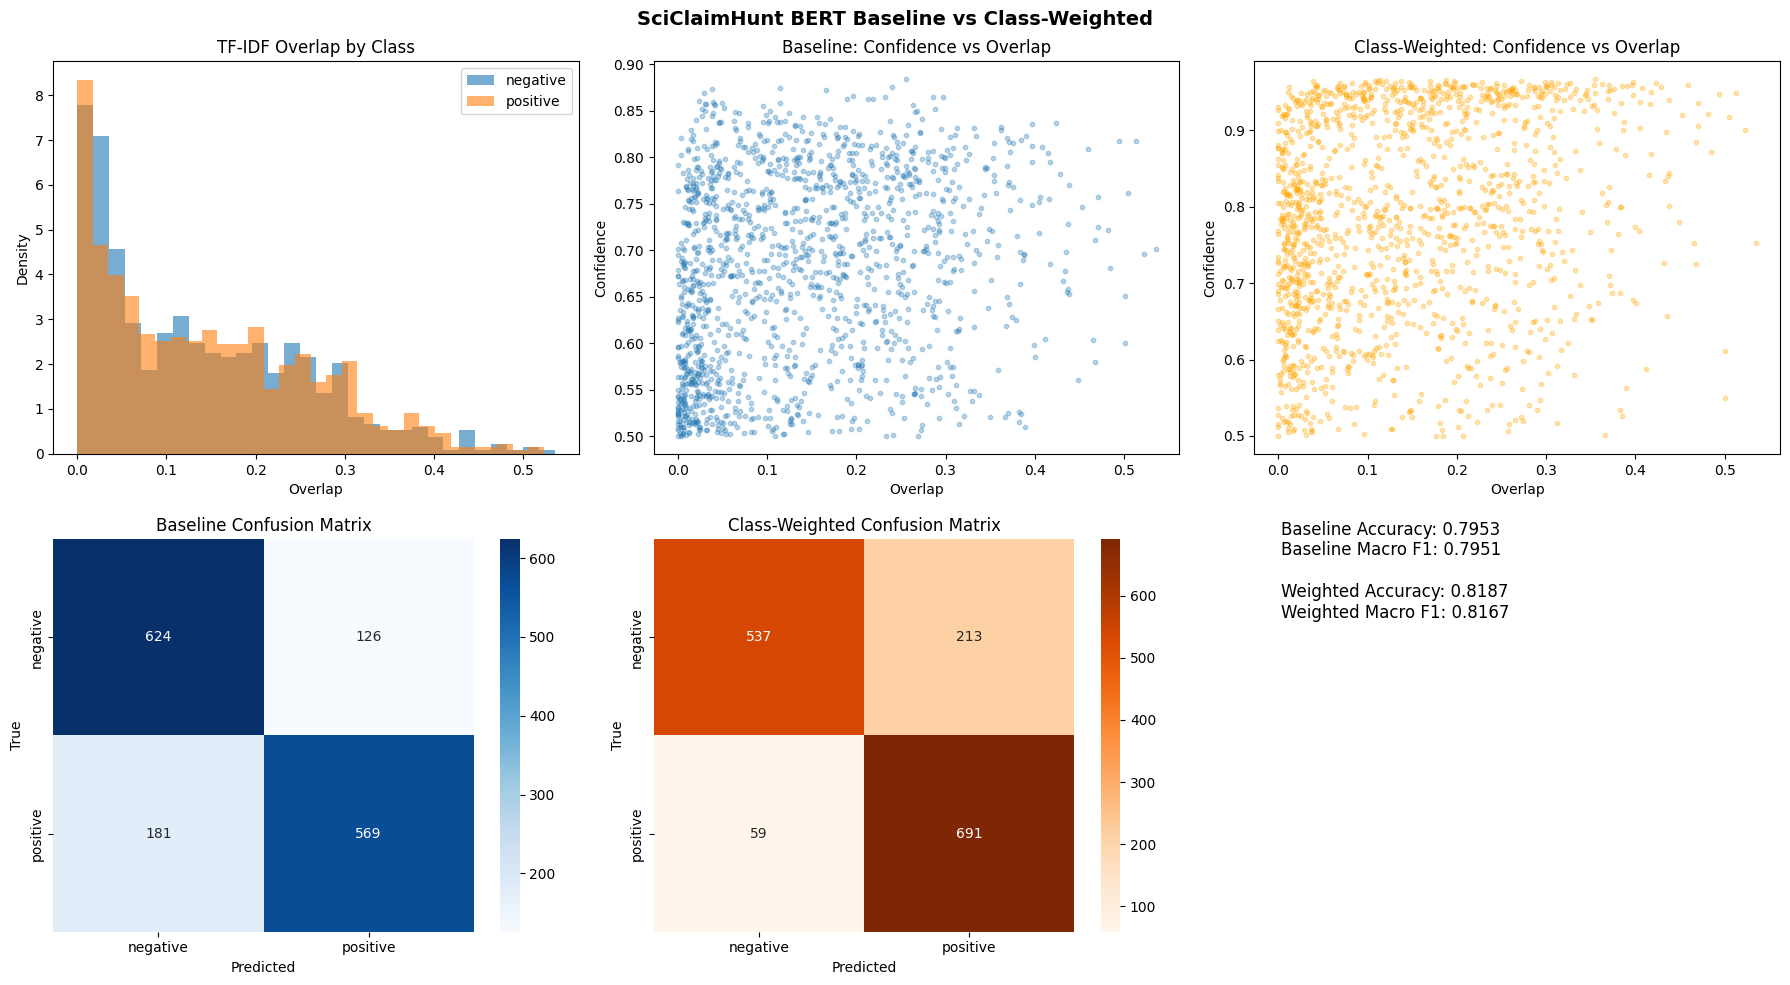

In [ ]:
def plot_basic_results(base_df, wt_df, base_preds, base_labels, wt_preds, wt_labels):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("SciClaimHunt BERT Baseline vs Class-Weighted", fontsize=14, fontweight="bold")

    ax = axes[0, 0]
    for name in LABEL_NAMES:
        sub = base_df[base_df["label_name"] == name]["overlap"]
        ax.hist(sub, bins=30, alpha=0.6, label=name, density=True)
    ax.set_title("TF-IDF Overlap by Class")
    ax.set_xlabel("Overlap")
    ax.set_ylabel("Density")
    ax.legend()

    ax = axes[0, 1]
    ax.scatter(base_df["overlap"], base_df["confidence"], alpha=0.3, s=10)
    ax.set_title("Baseline: Confidence vs Overlap")
    ax.set_xlabel("Overlap")
    ax.set_ylabel("Confidence")

    ax = axes[0, 2]
    ax.scatter(wt_df["overlap"], wt_df["confidence"], alpha=0.3, s=10, color="orange")
    ax.set_title("Class-Weighted: Confidence vs Overlap")
    ax.set_xlabel("Overlap")
    ax.set_ylabel("Confidence")

    ax = axes[1, 0]
    sns.heatmap(
        confusion_matrix(base_labels, base_preds),
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )
    ax.set_title("Baseline Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax = axes[1, 1]
    sns.heatmap(
        confusion_matrix(wt_labels, wt_preds),
        annot=True,
        fmt="d",
        cmap="Oranges",
        ax=ax,
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )
    ax.set_title("Class-Weighted Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax = axes[1, 2]
    b_acc = accuracy_score(base_labels, base_preds)
    w_acc = accuracy_score(wt_labels, wt_preds)
    b_f1 = f1_score(base_labels, base_preds, average="macro")
    w_f1 = f1_score(wt_labels, wt_preds, average="macro")
    ax.axis("off")
    ax.text(
        0.05, 0.8,
        f"Baseline Accuracy: {b_acc:.4f}\nBaseline Macro F1: {b_f1:.4f}\n\n"
        f"Weighted Accuracy: {w_acc:.4f}\nWeighted Macro F1: {w_f1:.4f}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

plot_basic_results(val_feat_df, wt_feat_df, base_preds, base_labels, wt_preds, wt_labels)

## Interpretation:
BERT is not strongly using lexical overlap as a shortcut (at least on this dataset)
In fact, high overlap might even confuse it slightly. <br>
Class weighting significantly changes class-wise performance but does not meaningfully affect lexical shortcut reliance.

# Future Work Analyses

## FW1 Synonym-Swap

In [ ]:
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


def get_synonym(word):
    syns = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            cand = lemma.name().replace("_", " ")
            if cand.lower() != word.lower():
                syns.add(cand)
    return sorted(syns)[0] if syns else None


def synonym_swap(text, p=0.2):
    try:
        tokens = word_tokenize(str(text))
    except LookupError:
        tokens = re.findall(r"\w+|[^\w\s]", str(text))

    out = []
    for tok in tokens:
        if re.fullmatch(r"[A-Za-z]+", tok) and len(tok) > 3 and random.random() < p:
            syn = get_synonym(tok)
            out.append(syn if syn else tok)
        else:
            out.append(tok)
    return " ".join(out)


def run_synonym_swap_test(model, df, tokenizer, device, max_len=MAX_LEN, p=0.2):
    # Returns confidence drop and accuracy delta after synonym swapping
    pert = df.copy()
    pert["claim"] = pert["claim"].apply(lambda x: synonym_swap(x, p=p))
    pert["evidence"] = pert["evidence"].apply(lambda x: synonym_swap(x, p=p))

    orig_ds = SciClaimHuntDataset(df, tokenizer, max_len=max_len)
    pert_ds = SciClaimHuntDataset(pert, tokenizer, max_len=max_len)
    orig_loader = DataLoader(orig_ds, batch_size=BATCH_SIZE, shuffle=False)
    pert_loader = DataLoader(pert_ds, batch_size=BATCH_SIZE, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    _, orig_acc, _, _, orig_probs = evaluate(model, orig_loader, criterion, device)
    _, pert_acc, _, _, pert_probs = evaluate(model, pert_loader, criterion, device)

    orig_conf = orig_probs.max(axis=1).mean()
    pert_conf = pert_probs.max(axis=1).mean()

    return {
        "orig_acc": float(orig_acc),
        "pert_acc": float(pert_acc),
        "acc_delta": float(pert_acc - orig_acc),
        "orig_conf": float(orig_conf),
        "pert_conf": float(pert_conf),
        "conf_drop": float(pert_conf - orig_conf),
    }

## FW2 Attention Masking

In [ ]:
def overlap_words(claim, evidence):
    claim_tokens = set(re.findall(r"\w+", str(claim).lower()))
    evidence_tokens = re.findall(r"\w+|[^\w\s]", str(evidence))
    return claim_tokens, evidence_tokens


def mask_overlap_in_evidence(claim, evidence):
    claim_tokens, evidence_tokens = overlap_words(claim, evidence)
    masked = []
    for tok in evidence_tokens:
        if re.fullmatch(r"\w+", tok) and tok.lower() in claim_tokens:
            masked.append("[MASK]")
        else:
            masked.append(tok)
    return " ".join(masked)


def run_attention_masking_test(model, df, tokenizer, device, max_len=MAX_LEN):
    # Masks overlapping evidence tokens and measures accuracy delta
    pert = df.copy()
    pert["evidence"] = pert.apply(
        lambda r: mask_overlap_in_evidence(r["claim"], r["evidence"]),
        axis=1,
    )

    orig_ds = SciClaimHuntDataset(df, tokenizer, max_len=max_len)
    pert_ds = SciClaimHuntDataset(pert, tokenizer, max_len=max_len)
    orig_loader = DataLoader(orig_ds, batch_size=BATCH_SIZE, shuffle=False)
    pert_loader = DataLoader(pert_ds, batch_size=BATCH_SIZE, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    _, orig_acc, _, _, _ = evaluate(model, orig_loader, criterion, device)
    _, pert_acc, _, _, _ = evaluate(model, pert_loader, criterion, device)

    return {
        "orig_acc": float(orig_acc),
        "masked_acc": float(pert_acc),
        "acc_delta": float(pert_acc - orig_acc),
    }


## FW3 Probe (Overlap -> CLS)

In [ ]:
def run_overlap_cls_probe(model, df, tokenizer, device, idf=None, max_len=MAX_LEN):

    # Using a linear probe to predict high-vs-low TF-IDF overlap from CLS embeddings
    # Chance is ~0.5 because the overlap split is median-balanced

    idf = build_idf(df) if idf is None else idf
    probe_df = compute_shortcut_features(df, idf)
    threshold = probe_df["overlap"].median()
    probe_df["overlap_bin"] = (probe_df["overlap"] >= threshold).astype(int)

    ds = SciClaimHuntDataset(probe_df, tokenizer, max_len=max_len)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    X = []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            ttype = batch["token_type_ids"].to(device)

            out = model(
                input_ids=ids,
                attention_mask=mask,
                token_type_ids=ttype,
                output_hidden_states=True,
                return_dict=True,
            )
            cls = out.hidden_states[-1][:, 0, :].detach().cpu().numpy()
            X.append(cls)

    X = np.concatenate(X, axis=0)
    y = probe_df["overlap_bin"].values

    idx = np.arange(len(y))
    tr_idx, te_idx = train_test_split(idx, test_size=0.3, random_state=SEED, stratify=y)

    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(X[tr_idx], y[tr_idx])
    pred = clf.predict(X[te_idx])

    return {
        "probe_acc": float(accuracy_score(y[te_idx], pred)),
        "probe_balanced_acc": float(balanced_accuracy_score(y[te_idx], pred)),
        "chance": 0.5,
        "threshold": float(threshold),
    }


## FW4 NEI Deep-Dive

In [ ]:
def nei_deep_dive_sciclaimhunt(y_true, y_pred, probs=None, nei_label=2):

    # SciClaimHunt is binary (negative/positive), so NEI is absent
    # This keeps the same FW4 slot and adds a binary uncertainty deep-dive

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    nei_mask = y_true == nei_label

    result = {
        "nei_present": bool(nei_mask.any()),
        "nei_rate": float(nei_mask.mean()),
        "note": "SciClaimHunt has no NEI class; labels are negative/positive.",
    }

    if nei_mask.any():
        non_nei_mask = ~nei_mask
        result.update({
            "nei_acc": float(accuracy_score(y_true[nei_mask], y_pred[nei_mask])),
            "non_nei_acc": float(accuracy_score(y_true[non_nei_mask], y_pred[non_nei_mask])),
        })
        result["gap"] = result["nei_acc"] - result["non_nei_acc"]

    if probs is not None:
        probs = np.array(probs)
        confidence = probs.max(axis=1)
        low_conf_cutoff = np.quantile(confidence, 0.25)
        low_conf_mask = confidence <= low_conf_cutoff
        high_conf_mask = confidence > low_conf_cutoff
        result.update({
            "low_conf_threshold": float(low_conf_cutoff),
            "low_conf_acc": float(accuracy_score(y_true[low_conf_mask], y_pred[low_conf_mask])),
            "higher_conf_acc": float(accuracy_score(y_true[high_conf_mask], y_pred[high_conf_mask])),
            "low_conf_share": float(low_conf_mask.mean()),
        })

    return result


## FW5 Error Analysis

In [ ]:
def error_analysis_shortcuts_sciclaimhunt(df, y_true, y_pred):
    tmp = df.copy()
    tmp["true"] = y_true
    tmp["pred"] = y_pred
    tmp["correct"] = (tmp["true"] == tmp["pred"]).astype(int)

    errors = tmp[tmp["correct"] == 0].copy()
    overlap_median = tmp["overlap"].median() if "overlap" in tmp else np.nan

    def shortcut_type(row):
        if "overlap" in row and row["overlap"] > overlap_median:
            return "high_overlap_failure"
        if "negation" in row and row["negation"] == 1:
            return "negation_failure"
        if row["pred"] == 0 and row["true"] == 1:
            return "false_negative_label_bias"
        if row["pred"] == 1 and row["true"] == 0:
            return "false_positive_label_bias"
        return "other"

    if len(errors):
        errors["shortcut"] = errors.apply(shortcut_type, axis=1)
        counts = errors["shortcut"].value_counts()
    else:
        errors["shortcut"] = []
        counts = pd.Series(dtype=int)

    dominant = counts.index[0] if len(counts) else None
    dominant_n = int(counts.iloc[0]) if len(counts) else 0
    total_err = len(errors)

    return {
        "total_errors": int(total_err),
        "dominant_shortcut": dominant,
        "dominant_count": dominant_n,
        "dominant_share": float(dominant_n / total_err) if total_err else np.nan,
        "counts": counts.to_dict(),
        "errors_df": errors,
    }


## Final

In [ ]:
def _is_torch_model(obj):
    return hasattr(obj, "eval") and hasattr(obj, "parameters") and callable(obj)


def _select_future_work_model():
    candidates = [
        ("baseline_model", "target", "baseline"),
        ("baseline_model_full", "full", "baseline"),
        ("weighted_model", "target", "weighted"),
        ("weighted_model_full", "full", "weighted"),
    ]

    for model_name, split_name, pred_name in candidates:
        obj = globals().get(model_name)
        if _is_torch_model(obj):
            print(f"Using {model_name} for Future Work analyses.")
            return obj, split_name, pred_name

    available = {
        name: type(globals().get(name)).__name__
        for name, _, _ in candidates
        if name in globals()
    }
    raise TypeError(
        "No trained PyTorch model found for Future Work analyses. "
        "Rerun the baseline or weighted training cell first. "
        f"Current candidates: {available}"
    )


fw_model, fw_split, fw_pred_source = _select_future_work_model()

if fw_split == "full":
    fw_df = val_df.copy()
    fw_idf = build_idf(train_df)
    fw_max_len = MAX_LEN
    if fw_pred_source == "baseline":
        fw_labels, fw_preds, fw_probs = base_labels_full, base_preds_full, base_probs_full
    else:
        fw_labels, fw_preds, fw_probs = wt_labels_full, wt_preds_full, wt_probs_full
else:
    fw_df = val_df_small.copy()
    fw_idf = build_idf(train_df_small)
    fw_max_len = SMALL_MAX_LEN
    if fw_pred_source == "baseline":
        fw_labels, fw_preds, fw_probs = base_labels, base_preds, base_probs
    else:
        fw_labels, fw_preds, fw_probs = wt_labels, wt_preds, wt_probs

# FW1
fw1 = run_synonym_swap_test(fw_model, fw_df, tokenizer, DEVICE, max_len=fw_max_len)
print("\nFW1 Synonym-Swap:", fw1)

# FW2
fw2 = run_attention_masking_test(fw_model, fw_df, tokenizer, DEVICE, max_len=fw_max_len)
print("\nFW2 Attention Masking:", fw2)

# FW3
fw3 = run_overlap_cls_probe(fw_model, fw_df, tokenizer, DEVICE, idf=fw_idf, max_len=fw_max_len)
print("\nFW3 Probe (Overlap -> CLS):", fw3)

# FW4
fw4 = nei_deep_dive_sciclaimhunt(fw_labels, fw_preds, probs=fw_probs, nei_label=2)
print("\nFW4 NEI Deep-Dive:", fw4)

# FW5
fw_feature_df = compute_shortcut_features(fw_df, fw_idf)
fw5 = error_analysis_shortcuts_sciclaimhunt(fw_feature_df, fw_labels, fw_preds)
print("\nFW5 Error Analysis:", {k: v for k, v in fw5.items() if k != "errors_df"})

# Keep a compact object for report-writing.
future_work_results = {
    "model_used": fw_pred_source,
    "split_used": fw_split,
    "FW1_synonym_swap": fw1,
    "FW2_attention_masking": fw2,
    "FW3_overlap_cls_probe": fw3,
    "FW4_nei_deep_dive": fw4,
    "FW5_error_analysis": {k: v for k, v in fw5.items() if k != "errors_df"},
}


Using baseline_model for Future Work analyses.

FW1 Synonym-Swap: {'orig_acc': 0.7953333333333333, 'pert_acc': 0.782, 'acc_delta': -0.013333333333333308, 'orig_conf': 0.6797214150428772, 'pert_conf': 0.6670457124710083, 'conf_drop': -0.012675702571868896}

FW2 Attention Masking: {'orig_acc': 0.7953333333333333, 'masked_acc': 0.6306666666666667, 'acc_delta': -0.16466666666666663}

FW3 Probe (Overlap -> CLS): {'probe_acc': 0.8133333333333334, 'probe_balanced_acc': 0.8133333333333334, 'chance': 0.5, 'threshold': 0.11998590100042647}

FW4 NEI Deep-Dive: {'nei_present': False, 'nei_rate': 0.0, 'note': 'SciClaimHunt has no NEI class; labels are negative/positive.', 'low_conf_threshold': 0.5865191221237183, 'low_conf_acc': 0.5706666666666667, 'higher_conf_acc': 0.8702222222222222, 'low_conf_share': 0.25}

FW5 Error Analysis: {'total_errors': 307, 'dominant_shortcut': 'high_overlap_failure', 'dominant_count': 141, 'dominant_share': 0.4592833876221498, 'counts': {'high_overlap_failure': 141, 'n

## Save results

In [ ]:
results = {
    "dataset": "SciClaimHunt",

    "sizes": {
        "train": len(train_df),
        "cal": len(cal_df),
        "val": len(val_df)
    },

    "baseline": {
        "accuracy": float(accuracy_score(base_labels, base_preds)),
        "macro_f1": float(f1_score(base_labels, base_preds, average="macro")),
        "f1_per_class": f1_score(base_labels, base_preds, average=None).tolist(),
        "confusion_matrix": confusion_matrix(base_labels, base_preds).tolist()
    },

    "class_weighted": {
        "accuracy": float(accuracy_score(wt_labels, wt_preds)),
        "macro_f1": float(f1_score(wt_labels, wt_preds, average="macro")),
        "f1_per_class": f1_score(wt_labels, wt_preds, average=None).tolist(),
        "confusion_matrix": confusion_matrix(wt_labels, wt_preds).tolist()
    },

    "calibration": {
        "temperature": float(T),
        "accuracy": float(accuracy_score(cal_labels, cal_preds)),
        "macro_f1": float(f1_score(cal_labels, cal_preds, average="macro")),
    },

    "shortcut_analysis": {
        "baseline": {
            "pearson_overlap_conf": float(pearsonr(val_feat_df["overlap"], val_feat_df["confidence"])[0]),
            "spearman_overlap_conf": float(spearmanr(val_feat_df["overlap"], val_feat_df["confidence"])[0]),
        },
        "class_weighted": {
            "pearson_overlap_conf": float(pearsonr(wt_feat_df["overlap"], wt_feat_df["confidence"])[0]),
            "spearman_overlap_conf": float(spearmanr(wt_feat_df["overlap"], wt_feat_df["confidence"])[0]),
        }
    }
}

save_path = os.path.join(OUTPUT_DIR, "results_summary_sciclaimhunt.json")

with open(save_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved results to:", save_path)

Saved results to: ./outputs_sciclaimhunt/results_summary_sciclaimhunt.json
